# Customer Churn EDA
## 1. Load and Inspect Raw Data

In [1]:
import pandas as pd
df = pd.read_csv("../data/raw/bank_churn_raw.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
df.shape

(10000, 14)

In [3]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

## 2. Data Cleaning

In [8]:
df_clean = df.copy()
df_clean = df_clean.drop(columns=["RowNumber", "CustomerId", "Surname"])
df_clean.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [10]:
df_clean.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [11]:
df_clean.to_csv("../data/processed/bank_churn_clean.csv", index=False)

In [13]:
df_enriched = df_clean.copy()

df_enriched["age_band"] = pd.cut(
    df_enriched["Age"],
    bins=[0, 30, 40, 50, 60, 100],
    labels=["<30", "30-40", "40-50", "50-60", "60+"]
)

df_enriched["tenure_band"] = pd.cut(
    df_enriched["Tenure"],
    bins=[-1, 2, 5, 8, 10],
    labels=["0-2", "3-5", "6-8", "9-10"]
)

df_enriched["balance_band"] = pd.cut(
    df_enriched["Balance"],
    bins=[-1, 0, 50000, 100000, 150000, 300000],
    labels=["0", "0-50k", "50k-100k", "100k-150k", "150k+"]
)

In [14]:
df_enriched.to_csv("../data/processed/bank_churn_enriched.csv", index=False)

## 3. SQL Analysis

In [2]:
import sqlite3
import pandas as pd

df_sql = pd.read_csv("data/processed/bank_churn_enriched.csv")
conn = sqlite3.connect(":memory:")
df_sql.to_sql("churn", conn, index=False, if_exists="replace")

10000

In [3]:
query = """
SELECT AVG(Exited) AS churn_rate
FROM churn;
"""
pd.read_sql_query(query, conn)

,churn_rate
0,0.2037


In [4]:
query = """
SELECT Gender, COUNT(*) AS customers, AVG(Exited) AS churn_rate
FROM churn
GROUP BY Gender
ORDER BY churn_rate DESC;
"""
pd.read_sql_query(query, conn)

,Gender,customers,churn_rate
0,Female,4543,0.250715
1,Male,5457,0.164559


In [5]:
query = """
SELECT Geography, COUNT(*) AS customers, AVG(Exited) AS churn_rate
FROM churn
GROUP BY Geography
ORDER BY churn_rate DESC;
"""
pd.read_sql_query(query, conn)

,Geography,customers,churn_rate
0,Germany,2509,0.324432
1,Spain,2477,0.166734
2,France,5014,0.161548


In [6]:
query = """
SELECT age_band, COUNT(*) AS customers, AVG(Exited) AS churn_rate
FROM churn
GROUP BY age_band
ORDER BY churn_rate DESC;
"""
pd.read_sql_query(query, conn)

,age_band,customers,churn_rate
0,50-60,797,0.562108
1,40-50,2320,0.339655
2,60+,464,0.247845
3,30-40,4451,0.120872
4,<30,1968,0.075203


In [7]:
query = """
SELECT tenure_band, COUNT(*) AS customers, AVG(Exited) AS churn_rate
FROM churn
GROUP BY tenure_band
ORDER BY churn_rate DESC;
"""
pd.read_sql_query(query, conn)

,tenure_band,customers,churn_rate
0,9-10,1474,0.213026
1,0-2,2496,0.211538
2,3-5,3010,0.207641
3,6-8,3020,0.188742


In [8]:
query = """
SELECT balance_band, COUNT(*) AS customers, AVG(Exited) AS churn_rate
FROM churn
GROUP BY balance_band
ORDER BY churn_rate DESC;
"""
pd.read_sql_query(query, conn)

,balance_band,customers,churn_rate
0,0-50k,75,0.346667
1,100k-150k,3830,0.257702
2,150k+,969,0.231166
3,50k-100k,1509,0.198807
4,0,3617,0.138236


In [9]:
query = """
SELECT IsActiveMember, COUNT(*) AS customers, AVG(Exited) AS churn_rate
FROM churn
GROUP BY IsActiveMember
ORDER BY churn_rate DESC;
"""
pd.read_sql_query(query, conn)

,IsActiveMember,customers,churn_rate
0,0,4849,0.268509
1,1,5151,0.142691


In [10]:
query = """
SELECT NumOfProducts, COUNT(*) AS customers, AVG(Exited) AS churn_rate
FROM churn
GROUP BY NumOfProducts
ORDER BY churn_rate DESC;
"""
pd.read_sql_query(query, conn)

,NumOfProducts,customers,churn_rate
0,4,60,1.000000
1,3,266,0.827068
2,1,5084,0.277144
3,2,4590,0.075817


## 4. Python EDA and Visualizations

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [13]:
df = pd.read_csv("data/processed/bank_churn_enriched.csv")

In [14]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,age_band,tenure_band,balance_band
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,40-50,0-2,0
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,40-50,0-2,50k-100k
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,40-50,6-8,150k+
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,30-40,0-2,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,40-50,0-2,100k-150k


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
 11  age_band         10000 non-null  object 
 12  tenure_band      10000 non-null  object 
 13  balance_band     10000 non-null  object 
dtypes: float64(2), int64(7), object(5)
memory usage: 1.1+ MB


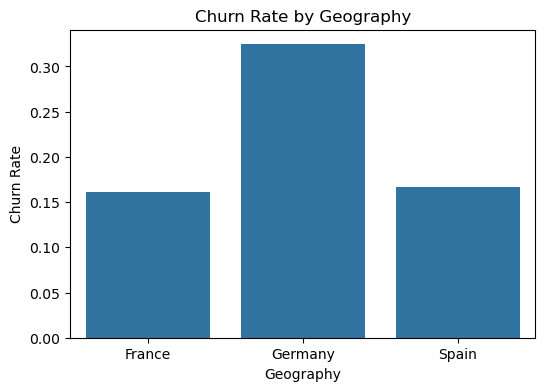

In [16]:
geo_churn = df.groupby("Geography")["Exited"].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=geo_churn, x="Geography", y="Exited")
plt.title("Churn Rate by Geography")
plt.ylabel("Churn Rate")
plt.xlabel("Geography")
plt.show()

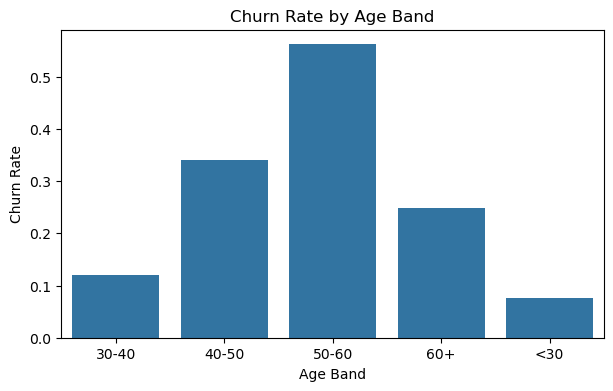

In [17]:
age_churn = df.groupby("age_band")["Exited"].mean().reset_index()

plt.figure(figsize=(7,4))
sns.barplot(data=age_churn, x="age_band", y="Exited")
plt.title("Churn Rate by Age Band")
plt.ylabel("Churn Rate")
plt.xlabel("Age Band")
plt.show()

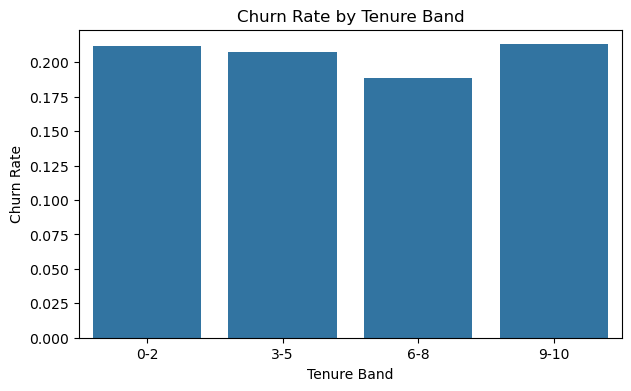

In [18]:
tenure_churn = df.groupby("tenure_band")["Exited"].mean().reset_index()

plt.figure(figsize=(7,4))
sns.barplot(data=tenure_churn, x="tenure_band", y="Exited")
plt.title("Churn Rate by Tenure Band")
plt.ylabel("Churn Rate")
plt.xlabel("Tenure Band")
plt.show()

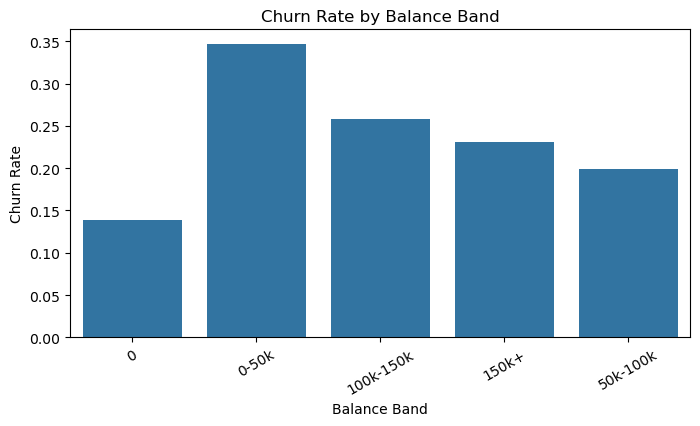

In [19]:
balance_churn = df.groupby("balance_band")["Exited"].mean().reset_index()

plt.figure(figsize=(8,4))
sns.barplot(data=balance_churn, x="balance_band", y="Exited")
plt.title("Churn Rate by Balance Band")
plt.ylabel("Churn Rate")
plt.xlabel("Balance Band")
plt.xticks(rotation=30)
plt.show()

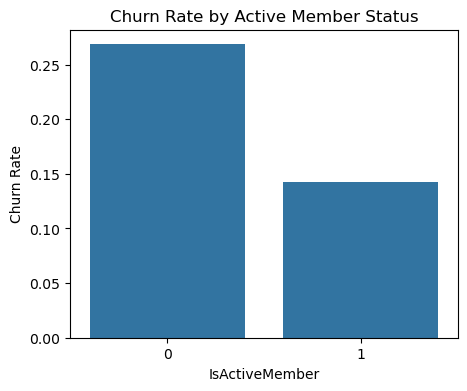

In [20]:
active_churn = df.groupby("IsActiveMember")["Exited"].mean().reset_index()

plt.figure(figsize=(5,4))
sns.barplot(data=active_churn, x="IsActiveMember", y="Exited")
plt.title("Churn Rate by Active Member Status")
plt.ylabel("Churn Rate")
plt.xlabel("IsActiveMember")
plt.show()

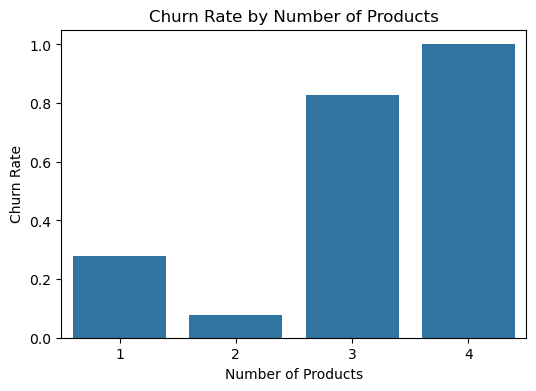

In [21]:
prod_churn = df.groupby("NumOfProducts")["Exited"].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=prod_churn, x="NumOfProducts", y="Exited")
plt.title("Churn Rate by Number of Products")
plt.ylabel("Churn Rate")
plt.xlabel("Number of Products")
plt.show()

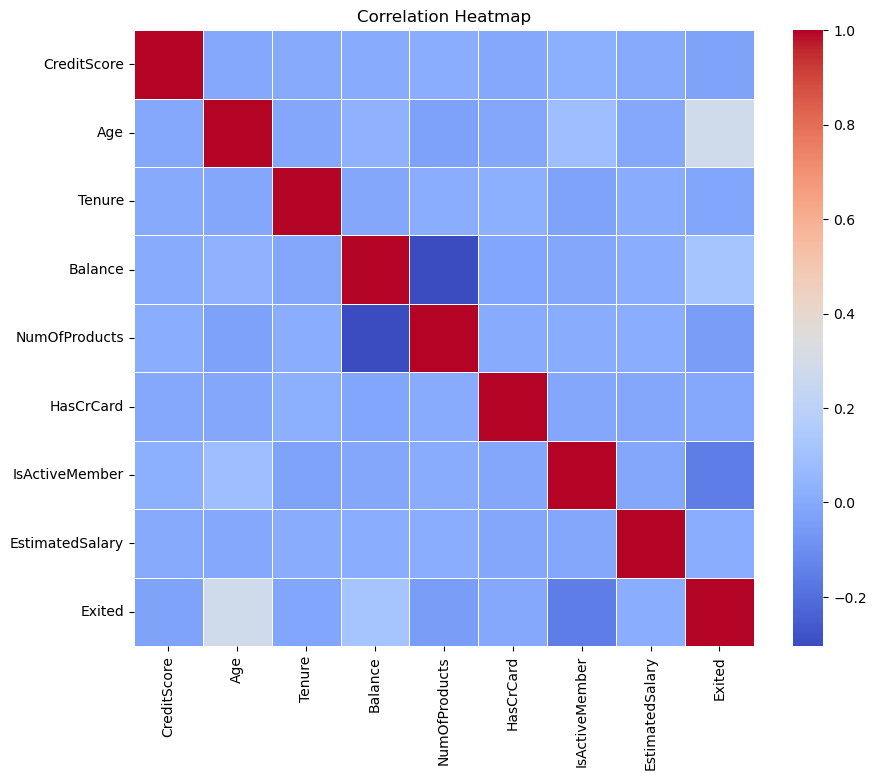

In [22]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()